In [1]:
import pandas as pd

df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [2]:
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(cm)
print("Accuracy :", acc)

[[57  1]
 [ 5 17]]
Accuracy : 0.925


In [16]:
# Feature scaling (fit on full features and keep scaled dataframe)
ss = StandardScaler()
x_scaled = ss.fit_transform(x)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled_df.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80



In [28]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

print(confusion_matrix(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[57  1]
 [ 5 17]]
Accuracy : 0.925
Precision : 0.9444444444444444
Recall : 0.7727272727272727
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80



Logistic regression model
TRAINING DATA:
True Negatives (TN): 181
False Positives (FP): 18
False Negatives (FN): 39
True Positives (TP): 82

Confusion Matrix:
[[181  18]
 [ 39  82]]

TESTING DATA:
True Negatives (TN): 57
False Positives (FP): 1
False Negatives (FN): 5
True Positives (TP): 17

Confusion Matrix:
[[57  1]
 [ 5 17]]



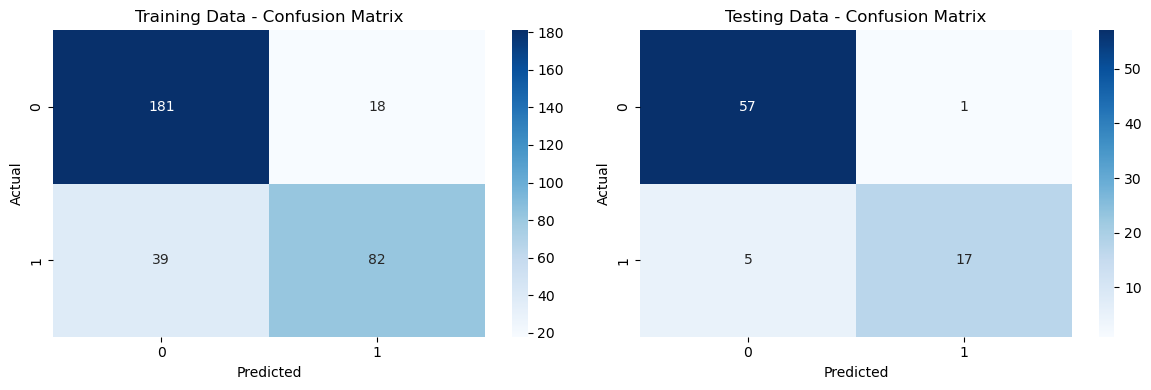

In [32]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create confusion matrices for both training and testing data
y_train_pred = model.predict(x_train)
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_pred)

# Create labels for confusion matrix
labels = ['TN', 'FP', 'FN', 'TP']

# Extract TP, TN, FP, FN for training data
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()

# Extract TP, TN, FP, FN for testing data
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

# Display results
print ("Logistic regression model")

print("TRAINING DATA:")
print(f"True Negatives (TN): {tn_train}")
print(f"False Positives (FP): {fp_train}")
print(f"False Negatives (FN): {fn_train}")
print(f"True Positives (TP): {tp_train}")
print(f"\nConfusion Matrix:\n{cm_train}\n")

print("TESTING DATA:")
print(f"True Negatives (TN): {tn_test}")
print(f"False Positives (FP): {fp_test}")
print(f"False Negatives (FN): {fn_test}")
print(f"True Positives (TP): {tp_test}")
print(f"\nConfusion Matrix:\n{cm_test}\n")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Data - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Testing Data - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=0)
model_dt.fit(x_train, y_train)

y_train_pred_dt = model_dt.predict(x_train)
y_test_pred_dt = model_dt.predict(x_test)

cm_train_dt = confusion_matrix(y_train, y_train_pred_dt)
cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)

tn_train_dt, fp_train_dt, fn_train_dt, tp_train_dt = cm_train_dt.ravel()
tn_test_dt, fp_test_dt, fn_test_dt, tp_test_dt = cm_test_dt.ravel()

print("Decesion Tree Model")
print("TRAINING DATA:")
print(f"TN: {tn_train_dt}, FP: {fp_train_dt}, FN: {fn_train_dt}, TP: {tp_train_dt}")
print(cm_train_dt)
print("\nTESTING DATA:")
print(f"TN: {tn_test_dt}, FP: {fp_test_dt}, FN: {fn_test_dt}, TP: {tp_test_dt}")
print(cm_test_dt)

Decesion Tree Model
TRAINING DATA:
TN: 199, FP: 0, FN: 1, TP: 120
[[199   0]
 [  1 120]]

TESTING DATA:
TN: 53, FP: 5, FN: 3, TP: 19
[[53  5]
 [ 3 19]]


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Create and train Random Forest model
model_rf = RandomForestClassifier(random_state=0)
model_rf.fit(x_train, y_train)

# Make predictions
y_train_pred_rf = model_rf.predict(x_train)
y_test_pred_rf = model_rf.predict(x_test)

# Create confusion matrices
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)

# Extract TP, TN, FP, FN
tn_train_rf, fp_train_rf, fn_train_rf, tp_train_rf = cm_train_rf.ravel()
tn_test_rf, fp_test_rf, fn_test_rf, tp_test_rf = cm_test_rf.ravel()

# Display results
print("RANDOM FOREST - TRAINING DATA:")
print(f"TN: {tn_train_rf}, FP: {fp_train_rf}, FN: {fn_train_rf}, TP: {tp_train_rf}")
print(f"Confusion Matrix:\n{cm_train_rf}\n")

print("RANDOM FOREST - TESTING DATA:")
print(f"TN: {tn_test_rf}, FP: {fp_test_rf}, FN: {fn_test_rf}, TP: {tp_test_rf}")
print(f"Confusion Matrix:\n{cm_test_rf}")

RANDOM FOREST - TRAINING DATA:
TN: 199, FP: 0, FN: 1, TP: 120
Confusion Matrix:
[[199   0]
 [  1 120]]

RANDOM FOREST - TESTING DATA:
TN: 55, FP: 3, FN: 3, TP: 19
Confusion Matrix:
[[55  3]
 [ 3 19]]


In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Create and train KNN model
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)

# Make predictions
y_train_pred_knn = model_knn.predict(x_train)
y_test_pred_knn = model_knn.predict(x_test)

# Create confusion matrices
cm_train_knn = confusion_matrix(y_train, y_train_pred_knn)
cm_test_knn = confusion_matrix(y_test, y_test_pred_knn)

# Extract TP, TN, FP, FN
tn_train_knn, fp_train_knn, fn_train_knn, tp_train_knn = cm_train_knn.ravel()
tn_test_knn, fp_test_knn, fn_test_knn, tp_test_knn = cm_test_knn.ravel()

# Display results
print("KNN Model ")
print("KNN - TRAINING DATA:")
print(f"TN: {tn_train_knn}, FP: {fp_train_knn}, FN: {fn_train_knn}, TP: {tp_train_knn}")
print(f"Confusion Matrix:\n{cm_train_knn}\n")

print("KNN - TESTING DATA:")
print(f"TN: {tn_test_knn}, FP: {fp_test_knn}, FN: {fn_test_knn}, TP: {tp_test_knn}")
print(f"Confusion Matrix:\n{cm_test_knn}")

KNN Model 
KNN - TRAINING DATA:
TN: 182, FP: 17, FN: 9, TP: 112
Confusion Matrix:
[[182  17]
 [  9 112]]

KNN - TESTING DATA:
TN: 55, FP: 3, FN: 1, TP: 21
Confusion Matrix:
[[55  3]
 [ 1 21]]
